<a href="https://colab.research.google.com/github/Sanmarquino/Modelos-Supervisado-y-No-Supervisados/blob/main/Machine_Learning_Modelos_Lineales_Ventas_Marketing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PROYECTO DE CIENCIA DE DATOS: Predicción de Ventas en Marketing

In [35]:
# Cargar librerías
# Tratamiento de Datos
import pandas as pd
import numpy as np

# Gráficos
import matplotlib.pyplot as plt
from matplotlib import style
import seaborn as sns

# Preprocesamiento y Modelo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
# ---> AGREGADO: Importamos mean_absolute_error
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge, Lasso
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV
import joblib

# Configuración de nuestros visuales
plt.rcParams['image.cmap'] = 'bwr'
plt.rcParams['savefig.bbox'] = 'tight'
style.use('ggplot')

# Ignorar las advertencias de paquetes y sus actualizaciones
import warnings
warnings.filterwarnings('ignore')

In [46]:
# ==============================================================================
# 1. Carga y exploración inicial de los datos
# ==============================================================================
print("--- 1. CARGA DE DATOS ---")
datos = pd.read_csv('dataset_marketing_ventas.csv')
display(datos.head())

# Estructura, Nulos y Estadísticas Descriptivas
print("\n--- ESTRUCTURA DEL DATASET ---")
datos.info()

print("\n--- VERIFICACIÓN DE VALORES NULOS ---")
display(datos.isnull().sum())

print("\n--- ESTADÍSTICAS DESCRIPTIVAS ---")
display(datos.describe())

--- 1. CARGA DE DATOS ---


,inversion_tv,inversion_radio,inversion_redes_sociales,inversion_periodico,ventas
0,93.49,33.43,74.16,24.40,50.40
1,99.80,40.86,89.91,26.03,42.57
2,87.41,41.63,77.81,30.89,40.24
3,136.14,61.82,113.05,43.43,58.63
4,164.64,86.94,151.48,52.44,77.16



--- ESTRUCTURA DEL DATASET ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   inversion_tv              10000 non-null  float64
 1   inversion_radio           10000 non-null  float64
 2   inversion_redes_sociales  10000 non-null  float64
 3   inversion_periodico       10000 non-null  float64
 4   ventas                    10000 non-null  float64
dtypes: float64(5)
memory usage: 390.8 KB

--- VERIFICACIÓN DE VALORES NULOS ---


,0
inversion_tv,0
inversion_radio,0
inversion_redes_sociales,0
inversion_periodico,0
ventas,0



--- ESTADÍSTICAS DESCRIPTIVAS ---


,inversion_tv,inversion_radio,inversion_redes_sociales,inversion_periodico,ventas
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,121.435897,56.705378,102.617074,32.780968,53.304320
std,51.847813,24.118073,43.415164,15.086090,19.216933
min,5.920000,7.150000,10.900000,0.000000,12.660000
25%,85.210000,40.017500,72.390000,22.477500,40.377500
50%,112.190000,52.555000,94.920000,30.755000,49.605000
75%,147.682500,68.880000,124.172500,40.950000,61.912500
max,677.000000,312.620000,566.080000,169.690000,344.810000



--- 2. ANÁLISIS DE CORRELACIÓN ---


,variable 1,variable 2,Correlacion,Valor Absoluto
2,inversion_tv,inversion_redes_sociales,0.979911,0.979911
10,inversion_redes_sociales,inversion_tv,0.979911,0.979911
5,inversion_radio,inversion_tv,0.970747,0.970747
1,inversion_tv,inversion_radio,0.970747,0.970747
11,inversion_redes_sociales,inversion_radio,0.968966,0.968966


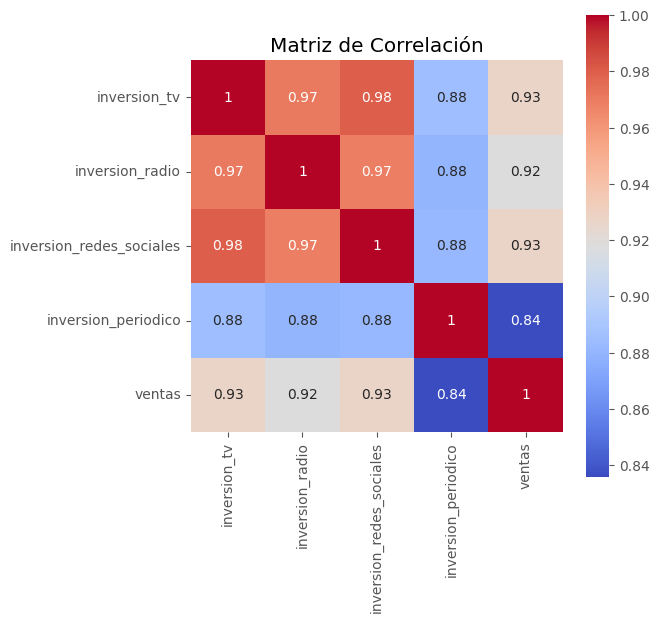


--- CORRELACIÓN DIRECTA CON VENTAS (Ordenada) ---


,ventas
ventas,1.000000
inversion_tv,0.927440
inversion_redes_sociales,0.927031
inversion_radio,0.918294
inversion_periodico,0.835763


In [37]:
# ==============================================================================
# 2. Análisis de Correlación
# ==============================================================================
print("\n--- 2. ANÁLISIS DE CORRELACIÓN ---")
def matriz_correlacion(corr_mat):
    corr_mat = corr_mat.stack().reset_index()
    corr_mat.columns = ['variable 1','variable 2','Correlacion']
    corr_mat = corr_mat.loc[corr_mat['variable 1'] != corr_mat['variable 2'], :]
    corr_mat['Valor Absoluto'] = np.abs(corr_mat['Correlacion'])
    corr_mat = corr_mat.sort_values('Valor Absoluto', ascending = False)
    return(corr_mat)

corr_matrix = datos.select_dtypes(include=['float','int']).corr(method='pearson')
display(matriz_correlacion(corr_matrix).head(5))

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6,6))
sns.heatmap(corr_matrix, square=True, ax=ax, annot=True, cmap='coolwarm')
ax.set_title('Matriz de Correlación')
plt.show()

# Identificar relación específica con VENTAS
print("\n--- CORRELACIÓN DIRECTA CON VENTAS (Ordenada) ---")
correlacion_ventas = corr_matrix['ventas'].sort_values(ascending=False)
display(correlacion_ventas)

In [38]:
# ==============================================================================
# 3 y 4. División de los datos y ESCALADO
# ==============================================================================
print("\n--- 3 y 4. DIVISIÓN Y ESCALADO ---")
X = datos[['inversion_tv', 'inversion_radio', 'inversion_redes_sociales', 'inversion_periodico']]

# Aplicamos logaritmo por la falta de normalidad en las ventas
y = np.log(datos['ventas'])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y.values.reshape(-1,1),
    test_size=0.2,
    random_state=1234,
    shuffle=True
)

# ESCALADO (Obligatorio para Ridge, Lasso y ElasticNet)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)


--- 3 y 4. DIVISIÓN Y ESCALADO ---


In [40]:
# ==============================================================================
# 5 y 6. Implementación y Evaluación: Mínimos Cuadrados Ordinarios (OLS)
# ==============================================================================
print("\n--- MODELO OLS (REGRESIÓN LINEAL) ---")
modelo_ols = LinearRegression()
modelo_ols.fit(X=X_train_scaled, y=y_train)

predicciones_ols = modelo_ols.predict(X=X_test_scaled).flatten()

# R2, MAE y RMSE completos
r2_ols = r2_score(y_true=y_test, y_pred=predicciones_ols)
rmse_ols = np.sqrt(mean_squared_error(y_true=y_test, y_pred=predicciones_ols))
mae_ols = mean_absolute_error(y_true=y_test, y_pred=predicciones_ols)

print(f'R2: {r2_ols:.4f} | RMSE: {rmse_ols:.4f} | MAE: {mae_ols:.4f}')


--- MODELO OLS (REGRESIÓN LINEAL) ---
R2: 0.8146 | RMSE: 0.1436 | MAE: 0.1106



--- MODELO RIDGE ---


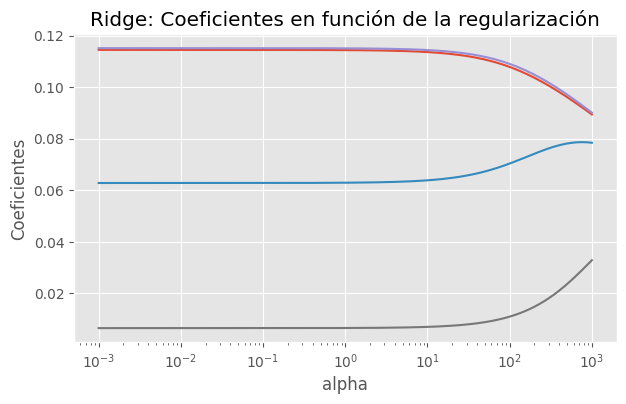

Mejor valor de alpha encontrado (Ridge): 16.6382
R2: 0.8145 | RMSE: 0.1436 | MAE: 0.1106


In [41]:
# ==============================================================================
# 5 y 6. Implementación y Evaluación: RIDGE REGRESSION
# ==============================================================================
print("\n--- MODELO RIDGE ---")
modelo_ridge = RidgeCV(alphas=np.logspace(-3, 3, 200), fit_intercept=True, store_cv_values=True)
_ = modelo_ridge.fit(X=X_train_scaled, y=y_train)

alphas_ridge = modelo_ridge.alphas
coefs_ridge = []
for alpha in alphas_ridge:
    modelo_temp = Ridge(alpha=alpha, fit_intercept=False)
    modelo_temp.fit(X_train_scaled, y_train)
    coefs_ridge.append(modelo_temp.coef_.flatten())

fig, ax = plt.subplots(figsize=(7,4))
ax.plot(alphas_ridge, coefs_ridge)
ax.set_xscale('log')
ax.set_title('Ridge: Coeficientes en función de la regularización')
ax.set_xlabel('alpha')
ax.set_ylabel('Coeficientes')
plt.show()

print(f'Mejor valor de alpha encontrado (Ridge): {modelo_ridge.alpha_:.4f}')

predicciones_ridge = modelo_ridge.predict(X=X_test_scaled).flatten()

# R2, MAE y RMSE completos
r2_ridge = r2_score(y_true=y_test, y_pred=predicciones_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_true=y_test, y_pred=predicciones_ridge))
mae_ridge = mean_absolute_error(y_true=y_test, y_pred=predicciones_ridge)

print(f'R2: {r2_ridge:.4f} | RMSE: {rmse_ridge:.4f} | MAE: {mae_ridge:.4f}')


--- MODELO LASSO ---


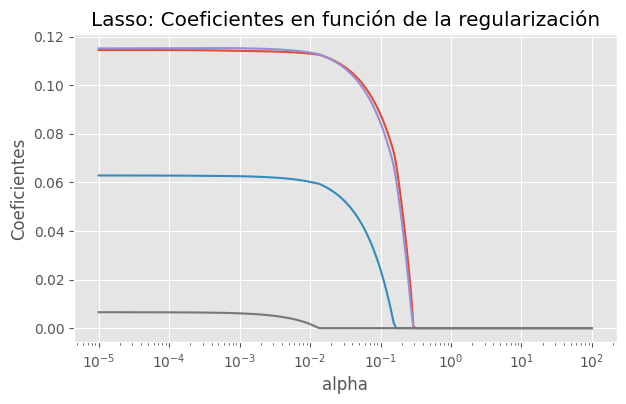

Mejor valor de alpha encontrado (Lasso): 0.000097
R2: 0.8146 | RMSE: 0.1436 | MAE: 0.1106


In [42]:
# ==============================================================================
# 5 y 6. Implementación y Evaluación: LASSO REGRESSION
# ==============================================================================
print("\n--- MODELO LASSO ---")
modelo_lasso = LassoCV(alphas=np.logspace(-5, 2, 200), cv=10, max_iter=10000)
_ = modelo_lasso.fit(X=X_train_scaled, y=y_train.flatten())

alphas_lasso = modelo_lasso.alphas_
coefs_lasso = []
for alpha in alphas_lasso:
    modelo_temp = Lasso(alpha=alpha, fit_intercept=False)
    modelo_temp.fit(X_train_scaled, y_train)
    coefs_lasso.append(modelo_temp.coef_.flatten())

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(alphas_lasso, coefs_lasso)
ax.set_xscale('log')
ax.set_ylabel('Coeficientes')
ax.set_xlabel('alpha')
ax.set_title('Lasso: Coeficientes en función de la regularización')
plt.show()

print(f'Mejor valor de alpha encontrado (Lasso): {modelo_lasso.alpha_:.6f}')

predicciones_lasso = modelo_lasso.predict(X=X_test_scaled)

# R2, MAE y RMSE completos
r2_lasso = r2_score(y_true=y_test, y_pred=predicciones_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_true=y_test, y_pred=predicciones_lasso))
mae_lasso = mean_absolute_error(y_true=y_test, y_pred=predicciones_lasso)

print(f'R2: {r2_lasso:.4f} | RMSE: {rmse_lasso:.4f} | MAE: {mae_lasso:.4f}')

In [43]:
# ==============================================================================
# 5 y 6. Implementación y Evaluación: ELASTIC NET
# ==============================================================================
print("\n--- MODELO ELASTIC NET ---")
modelo_elastic = ElasticNetCV(
    l1_ratio=[0.1, 0.5, 0.7, 0.9, 0.95, 0.99],
    alphas=np.logspace(-5, 2, 200),
    cv=10,
    max_iter=10000
)
_ = modelo_elastic.fit(X=X_train_scaled, y=y_train.flatten())

print(f'Mejor valor de alpha encontrado (ElasticNet): {modelo_elastic.alpha_:.6f}')
print(f'Mejor valor de l1_ratio_ encontrado: {modelo_elastic.l1_ratio_}')

predicciones_elastic = modelo_elastic.predict(X=X_test_scaled)

# R2, MAE y RMSE completos
r2_elastic_net = r2_score(y_true=y_test, y_pred=predicciones_elastic)
rmse_elastic = np.sqrt(mean_squared_error(y_true=y_test, y_pred=predicciones_elastic))
mae_elastic = mean_absolute_error(y_true=y_test, y_pred=predicciones_elastic)

print(f'R2: {r2_elastic_net:.4f} | RMSE: {rmse_elastic:.4f} | MAE: {mae_elastic:.4f}')


--- MODELO ELASTIC NET ---
Mejor valor de alpha encontrado (ElasticNet): 0.001517
Mejor valor de l1_ratio_ encontrado: 0.1
R2: 0.8146 | RMSE: 0.1436 | MAE: 0.1106



--- COMPARACIÓN DE COEFICIENTES ---


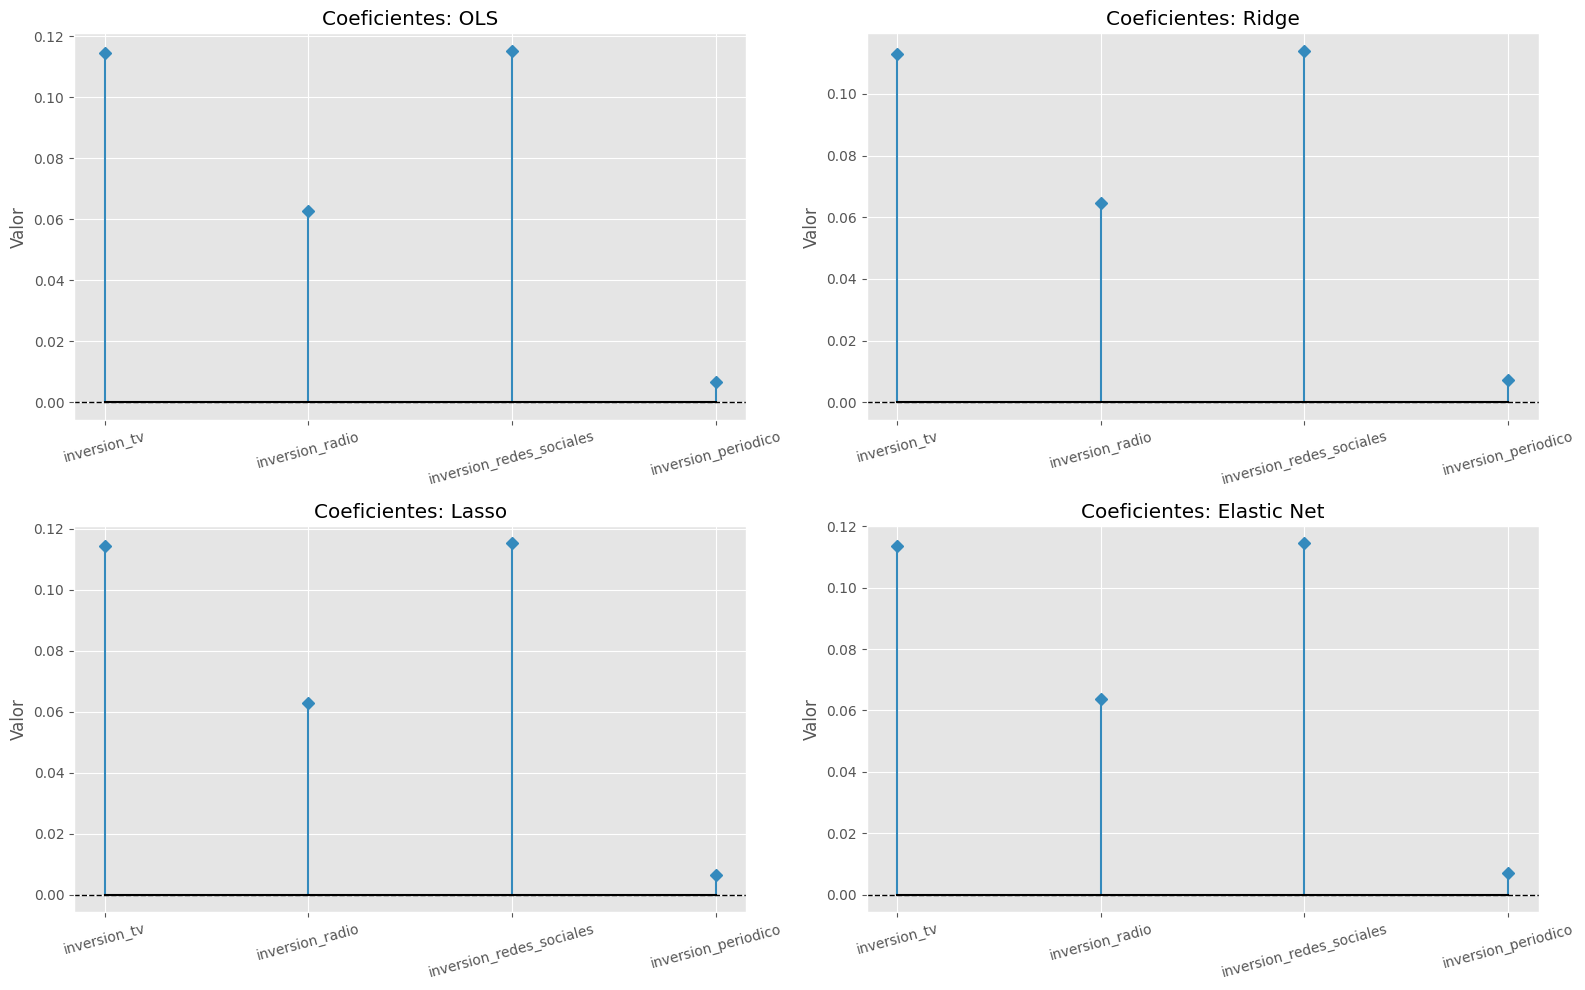

In [44]:
# ==============================================================================
# COMPARACIÓN DE COEFICIENTES (STEM PLOT)
# ==============================================================================
print("\n--- COMPARACIÓN DE COEFICIENTES ---")
modelos_finales = {
    'OLS': modelo_ols,
    'Ridge': modelo_ridge,
    'Lasso': modelo_lasso,
    'Elastic Net': modelo_elastic
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, (nombre, modelo) in enumerate(modelos_finales.items()):
    df_coeficientes = pd.DataFrame({
        'predictor': X_train_scaled.columns,
        'coef': modelo.coef_.flatten()
    })

    ax = axes[i]
    ax.stem(df_coeficientes.predictor, df_coeficientes.coef, markerfmt='D', linefmt='C1-', basefmt='k-')
    ax.set_title(f'Coeficientes: {nombre}')
    ax.set_ylabel('Valor')
    ax.tick_params(axis='x', rotation=15, labelsize=10)
    ax.axhline(y=0, color='black', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()


--- COMPARACIÓN FINAL DE MODELOS (R2, RMSE, MAE) ---


,Modelo,R2,RMSE,MAE
0,OLS,0.814588,0.143588,0.110559
1,Ridge,0.814520,0.143615,0.110580
2,Lasso,0.814605,0.143581,0.110557
3,Elastic Net,0.814569,0.143595,0.110569


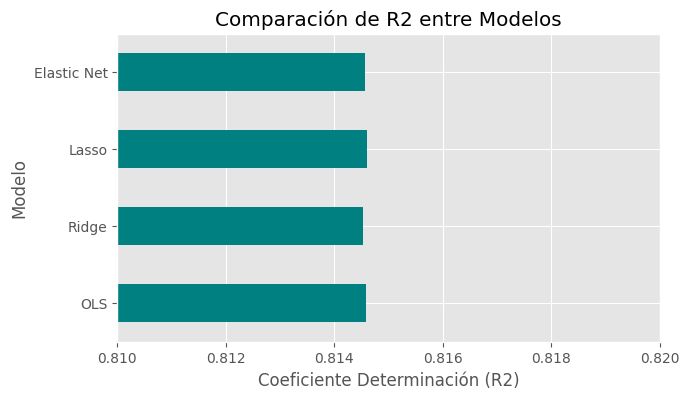

['modelo_marketing_ventas.pkl']

In [45]:
# ==============================================================================
# COMPARACIÓN FINAL DE MÉTRICAS (PASO 6 COMPLETO)
# ==============================================================================
print("\n--- COMPARACIÓN FINAL DE MODELOS (R2, RMSE, MAE) ---")

# ---> AGREGADO: Tabla comparativa completa con todas las métricas
df_comparacion = pd.DataFrame({
    'Modelo': ['OLS', 'Ridge', 'Lasso', 'Elastic Net'],
    'R2': [r2_ols, r2_ridge, r2_lasso, r2_elastic_net],
    'RMSE': [rmse_ols, rmse_ridge, rmse_lasso, rmse_elastic],
    'MAE': [mae_ols, mae_ridge, mae_lasso, mae_elastic]
})

display(df_comparacion)

# Gráfico de R2
fig, ax = plt.subplots(figsize=(7,4))
df_comparacion_r2 = df_comparacion[['Modelo', 'R2']].set_index('Modelo')
df_comparacion_r2.plot(kind='barh', ax=ax, color='teal', legend=False)
ax.set_xlabel('Coeficiente Determinación (R2)')
ax.set_title('Comparación de R2 entre Modelos')
plt.xlim(0.81, 0.82)
plt.show()

# Exportar el mejor modelo (Ej. Lasso)
joblib.dump(modelo_lasso, 'modelo_marketing_ventas.pkl')

# Interpretación de resultados

# ¿Qué canal de marketing parece tener mayor impacto en las ventas?

Con base en los resultados del modelo de regresión lineal (OLS) y los modelos regularizados, los canales con mayor impacto son las Redes Sociales y la Televisión, seguidos por la Radio. Al observar el gráfico de "Comparación de Coeficientes", las líneas correspondientes a inversion_redes_sociales e inversion_tv son sistemáticamente las más altas. Además, el análisis de correlación inicial respalda este hallazgo, mostrando que ambos canales (TV y Redes Sociales) tienen una correlación altísima con las ventas (0.93 para ambos).

# ¿Qué modelo obtuvo mejor desempeño?

Al evaluar el coeficiente de determinación (R²) sobre el conjunto de pruebas, el modelo Lasso obtuvo el mejor desempeño general, logrando un $R^2 = 0.8146$ y manteniendo los niveles de error más bajos en MAE y RMSE. Aunque la diferencia numérica en el R² es mínima respecto a los otros modelos, Lasso es el mejor porque logra esta métrica optimizando el modelo a través de su capacidad de selección de variables (eliminando el peso de los canales redundantes).

# ¿Existen diferencias significativas entre los modelos?

En términos del coeficiente de determinación (R²), no existen diferencias drásticas; todos los modelos explican aproximadamente el $81.4\%$ de la varianza en las ventas logarítmicas. Los valores son prácticamente idénticos (OLS: 0.814588, Ridge: 0.814520, Lasso: 0.814605, Elastic Net: 0.814569).
La diferencia significativa no recae en el poder predictivo (R²), sino en el manejo interno de la multicolinealidad. Ridge penalizó los coeficientes acercándolos a cero pero sin anularlos , mientras que Lasso aplicó un encogimiento más agresivo para simplificar el modelo debido a las altas correlaciones que existen entre las variables predictoras.




# ¿Qué variables parecen ser menos relevantes para el modelo?

El canal de marketing menos relevante es, de forma concluyente, la Inversión en Periódico.
En la matriz de correlación inicial, ya se observaba que era la variable con la menor relación directa con las ventas (0.84). Esta tendencia se confirmó en todos los modelos predictivos. Si se observa la gráfica comparativa de "Coeficientes", el valor del periódico es siempre el más cercano a cero, sin importar si usamos Mínimos Cuadrados Ordinarios o una penalización regularizada (Lasso, Ridge o Elastic Net). Esto indica que, en el contexto de este mix de medios, el presupuesto destinado a los periódicos no genera un aporte marginal significativo en la predicción final de las ventas.